In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load the data

df = pd.read_csv('Jobs_dataset.csv') 

In [3]:
print(df.shape)

(4653, 17)


In [4]:
df.head()

,job_id,job_title,company,location,salary_min,salary_max,description,country,search_keyword,experience_required,degree_required,skills,num_skills,job_level,is_remote,salary_avg,has_salary
0,5710345523,data scientist,Empnéo ICT,India,NaN,NaN,Job description Lead Data Scientist — Analytic...,India,data scientist,8.0,Not specified,[],0,Mid,False,NaN,False
1,5676535670,data scientist,ADM,"Bangalore, Karnataka",NaN,NaN,"Data Scientist Bengaluru, India Position Summa...",India,data scientist,NaN,Not specified,[],0,Mid,False,NaN,False
2,5705677339,data scientist,v4c.ai,India,NaN,NaN,Overview: The Data Scientist supports the deve...,India,data scientist,NaN,Not specified,['machine learning'],1,Mid,False,NaN,False
3,5689758521,data scientist,Kotak Mahindra Bank,"Bangalore, Karnataka",NaN,NaN,Hiring for Data Scientist Role Work location: ...,India,data scientist,10.0,Not specified,[],0,Mid,False,NaN,False
4,5709942304,data scientist,Whitefield Careers,"Bangalore, Karnataka",NaN,NaN,Data Scientist Location: Bangalore Experience:...,India,data scientist,4.0,Not specified,['machine learning'],1,Mid,False,NaN,False


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   job_id               4653 non-null   int64  
 1   job_title            4653 non-null   object 
 2   company              4652 non-null   object 
 3   location             4653 non-null   object 
 4   salary_min           2299 non-null   float64
 5   salary_max           2295 non-null   float64
 6   description          4653 non-null   object 
 7   country              4653 non-null   object 
 8   search_keyword       4653 non-null   object 
 9   experience_required  487 non-null    float64
 10  degree_required      4653 non-null   object 
 11  skills               4653 non-null   object 
 12  num_skills           4653 non-null   int64  
 13  job_level            4653 non-null   object 
 14  is_remote            4653 non-null   bool   
 15  salary_avg           2299 non-null   f

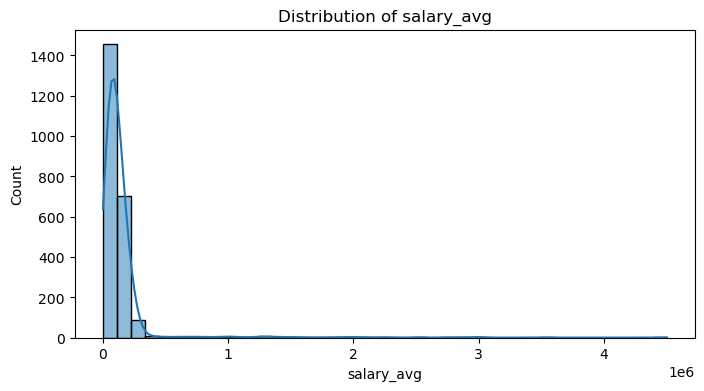

In [6]:
df['salary_avg'].describe()

plt.figure(figsize=(8,4))
sns.histplot(df['salary_avg'].dropna(), bins=40, kde=True)
plt.title('Distribution of salary_avg')
plt.show()

In [7]:
df.describe()

,job_id,salary_min,salary_max,experience_required,num_skills,salary_avg
count,4.653000e+03,2.299000e+03,2.295000e+03,487.000000,4653.000000,2.299000e+03
mean,5.639829e+09,1.171822e+05,1.491949e+05,23.969199,0.383838,1.330675e+05
std,3.094779e+08,1.826840e+05,3.461697e+05,60.676816,0.680850,2.554015e+05
min,1.155088e+09,0.000000e+00,1.100000e+01,1.000000,0.000000,1.000000e+01
25%,5.679737e+09,5.301667e+04,5.720662e+04,5.000000,0.000000,5.508915e+04
50%,5.696178e+09,8.288952e+04,9.118422e+04,7.000000,0.000000,8.822215e+04
75%,5.704005e+09,1.358604e+05,1.450000e+05,12.000000,1.000000,1.403207e+05
max,5.711046e+09,3.000000e+06,7.000000e+06,360.000000,5.000000,4.500000e+06


In [8]:
#Investigating the experience required column

df['experience_required'].value_counts().sort_index(ascending=False).head(10)

experience_required
360.0    12
200.0     3
175.0     3
165.0     1
160.0     1
150.0     2
130.0     2
125.0     2
100.0     1
90.0      1
Name: count, dtype: int64

In [9]:
#Checking the rows that are above 50

df[df['experience_required'] > 50]['experience_required'].describe()

count     43.000000
mean     178.883721
std      122.378844
min       56.000000
25%       60.000000
50%      150.000000
75%      360.000000
max      360.000000
Name: experience_required, dtype: float64

In [10]:
df.loc[df['experience_required'] > 50, 'experience_required'] = df['experience_required'] / 12

df['experience_required'].describe()

count    487.000000
mean       9.490760
std        8.383092
min        1.000000
25%        5.000000
50%        7.000000
75%       10.000000
max       50.000000
Name: experience_required, dtype: float64

In [11]:
## Confirming currency mixing across countries
df.groupby('country')['salary_avg'].describe()

,count,mean,std,min,25%,50%,75%,max
country,,,,,,,,
Australia,97.0,1.537013e+05,69004.414743,10.00,117000.000,157500.00,208000.000,325000.00
Canada,240.0,1.160524e+05,47765.762719,41.00,88832.000,110000.00,141000.000,294500.00
India,63.0,1.293216e+06,941359.291917,78.00,600000.000,1050000.00,1850000.000,4500000.00
UK,949.0,5.602856e+04,25172.550007,24123.61,35975.820,50292.73,67433.260,208000.00
USA,950.0,1.352808e+05,54427.846430,43449.42,92436.175,126332.88,173087.215,368271.97


In [12]:
#Convert all salaries to USD using approximate exchange rates
## Applying currency conversion
exchange_rates = {
    'USD': 1.00,
    'GBP': 1.27,
    'CAD': 0.74,
    'INR': 0.012,
    'AUD': 0.66
}

country_to_currency = {
    'USA': 'USD',
    'UK': 'GBP',
    'Canada': 'CAD',
    'India': 'INR',
    'Australia': 'AUD'
}

df['currency'] = df['country'].map(country_to_currency)
df['exchange_rate'] = df['currency'].map(exchange_rates)

for col in ['salary_min', 'salary_max', 'salary_avg']:
    df[col] = df[col] * df['exchange_rate']

df.groupby('country')['salary_avg'].describe()   

,count,mean,std,min,25%,50%,75%,max
country,,,,,,,,
Australia,97.0,101442.874330,45542.913730,6.6000,77220.0000,103950.0000,137280.0000,214500.00
Canada,240.0,85878.766750,35346.664412,30.3400,65735.6800,81400.0000,104340.0000,217930.00
India,63.0,15518.586286,11296.311503,0.9360,7200.0000,12600.0000,22200.0000,54000.00
UK,949.0,71156.272217,31969.138509,30636.9847,45689.2914,63871.7671,85640.2402,264160.00
USA,950.0,135280.836442,54427.846430,43449.4200,92436.1750,126332.8800,173087.2150,368271.97


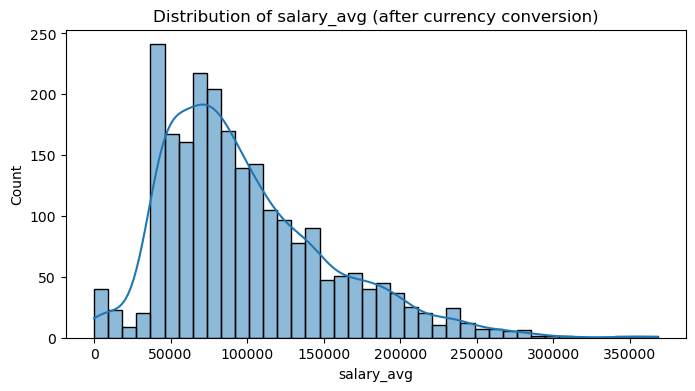

In [13]:
#Re-check the distribution shape now that currency is fixed
plt.figure(figsize=(8,4))
sns.histplot(df['salary_avg'].dropna(), bins=40, kde=True)
plt.title('Distribution of salary_avg (after currency conversion)')
plt.show()

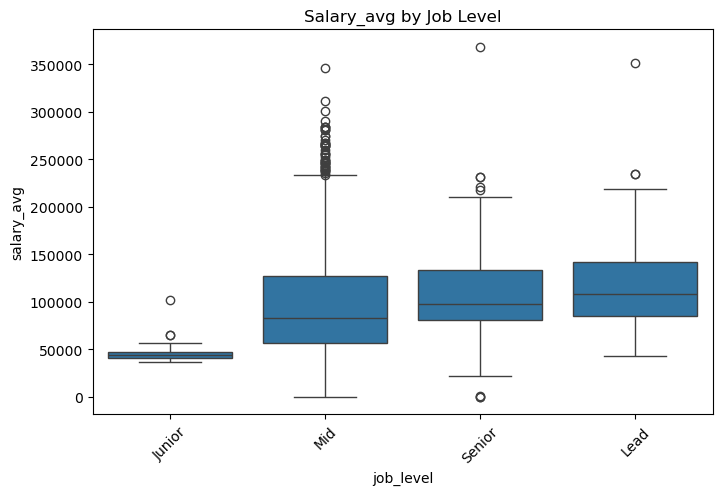

In [14]:
#Checking the salary avg by job level
level_order = ['Junior', 'Mid', 'Senior', 'Lead']

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='job_level', y='salary_avg', order=level_order)
plt.title('Salary_avg by Job Level')
plt.xticks(rotation=45)
plt.show()

In [15]:
## Splitting off rows with usable salary_avg

df_modeling = df[df['has_salary'] == True].copy()

print(df_modeling.shape)

(2295, 19)


In [16]:
## Checking for duplicates

df_modeling.duplicated().sum()

np.int64(0)

In [17]:
## Label encoding for the countries column

df_modeling = pd.get_dummies(df_modeling, columns=['country'], drop_first=True)

In [18]:
df_modeling.head()

,job_id,job_title,company,location,salary_min,salary_max,description,search_keyword,experience_required,degree_required,...,job_level,is_remote,salary_avg,has_salary,currency,exchange_rate,country_Canada,country_India,country_UK,country_USA
631,3175702626,machine learning engineer,Marj Technologies,"Noida, Ghaziabad",8400.0,12000.0,Job Description We are looking for a highly ca...,machine learning engineer,NaN,Not specified,...,Mid,False,10200.0,True,INR,0.012,False,True,False,False
634,4514376236,machine learning engineer,Qrata,"Bangalore, Karnataka",20400.0,48000.0,Role: Machine Learning Engineer As a machine l...,machine learning engineer,NaN,Not specified,...,Mid,False,34200.0,True,INR,0.012,False,True,False,False
635,5552722462,machine learning engineer,Innover Systems,"Pune, Maharashtra",4800.0,12000.0,Position: Machine Learning Engineer Job Type: ...,machine learning engineer,NaN,Not specified,...,Mid,False,8400.0,True,INR,0.012,False,True,False,False
636,3987216053,machine learning engineer,Thena,"Bangalore, Karnataka",18000.0,28800.0,We at Thena are looking for a Machine Learning...,machine learning engineer,4.0,Not specified,...,Mid,False,23400.0,True,INR,0.012,False,True,False,False
637,4708090721,machine learning engineer,LMES Academy,"Chennai, Tamil Nadu",8400.0,18000.0,Company Name : LMES Academy Private Limited We...,machine learning engineer,4.0,Not specified,...,Mid,False,13200.0,True,INR,0.012,False,True,False,False


In [19]:
#Job level ordinal encoding

level_order = {'Junior': 0, 'Mid': 1, 'Senior': 2, 'Lead': 3}
df_modeling['job_level_encoded'] = df_modeling['job_level'].map(level_order)

#convert True/False into 1/0 directly
df_modeling['is_remote'] = df_modeling['is_remote'].astype(int)

In [20]:
df_modeling[['job_level', 'job_level_encoded', 'is_remote']].tail(10)

,job_level,job_level_encoded,is_remote
4582,Senior,2,0
4584,Senior,2,0
4587,Senior,2,0
4589,Mid,1,0
4590,Senior,2,0
4591,Senior,2,0
4596,Mid,1,0
4600,Mid,1,0
4637,Mid,1,0
4643,Mid,1,0


In [21]:
#Processing the skills column

df_modeling['skills'].head(10)

631                       ['machine learning', 'aws']
634                              ['machine learning']
635                              ['machine learning']
636                              ['machine learning']
637                              ['machine learning']
639                    ['python', 'machine learning']
640                              ['machine learning']
641    ['python', 'sql', 'machine learning', 'spark']
644                              ['machine learning']
647                              ['machine learning']
Name: skills, dtype: object

In [22]:
#Verifying the data type 

type(df_modeling['skills'].iloc[0])

str

In [23]:
import ast

def safe_parse(x):
    if isinstance(x, str):
        return ast.literal_eval(x)
    return x  # already a list, leave it alone

df_modeling['skills'] = df_modeling['skills'].apply(safe_parse)

current_value = df_modeling['skills'].iloc[0]
print("Type:", type(current_value))
print("Value:", current_value)

Type: <class 'list'>
Value: ['machine learning', 'aws']


In [24]:
for skill in ['python', 'sql', 'spark', 'aws']:
    df_modeling[f'has_{skill}'] = df_modeling['skills'].apply(lambda skills_list: skill in skills_list)

df_modeling[['skills', 'has_python', 'has_sql', 'has_spark', 'has_aws']].head(10)

,skills,has_python,has_sql,has_spark,has_aws
631,"[machine learning, aws]",False,False,False,True
634,[machine learning],False,False,False,False
635,[machine learning],False,False,False,False
636,[machine learning],False,False,False,False
637,[machine learning],False,False,False,False
639,"[python, machine learning]",True,False,False,False
640,[machine learning],False,False,False,False
641,"[python, sql, machine learning, spark]",True,True,True,False
644,[machine learning],False,False,False,False
647,[machine learning],False,False,False,False


In [27]:
#Verifying the num_skills columns

df_modeling['actual_skill_count'] = df_modeling['skills'].apply(len)
df_modeling[['skills', 'num_skills', 'actual_skill_count']].head(10)

,skills,num_skills,actual_skill_count
631,"[machine learning, aws]",2,2
634,[machine learning],1,1
635,[machine learning],1,1
636,[machine learning],1,1
637,[machine learning],1,1
639,"[python, machine learning]",2,2
640,[machine learning],1,1
641,"[python, sql, machine learning, spark]",4,4
644,[machine learning],1,1
647,[machine learning],1,1


In [38]:
#Feature engineering for salary range
df_modeling['salary_range'] = df_modeling['salary_max'] - df_modeling['salary_min']

#Feature engineering for is_senior flag
df_modeling['is_senior'] = df_modeling['job_level'].isin(['Senior', 'Lead']).astype(int)

In [39]:
def experience_tier(years):
    if pd.isna(years):
        return 'Unknown'
    elif years <= 2:
        return 'Entry'
    elif years <= 5:
        return 'Junior'
    elif years <= 10:
        return 'Mid'
    else:
        return 'Senior'

df_modeling['experience_tier'] = df_modeling['experience_required'].apply(experience_tier)

In [40]:
df_modeling['experience_tier'].value_counts()

experience_tier
Unknown    2222
Junior       30
Senior       22
Mid          16
Entry         5
Name: count, dtype: int64

#####there isn't enough real data to learn a reliable pattern across 
the four experience tiers

In [41]:
#Simplify to just "has_experience_data" (yes/no)

df_modeling['has_experience_data'] = (df_modeling['experience_tier'] != 'Unknown').astype(int)

df_modeling['has_experience_data'].value_counts()

has_experience_data
0    2222
1      73
Name: count, dtype: int64

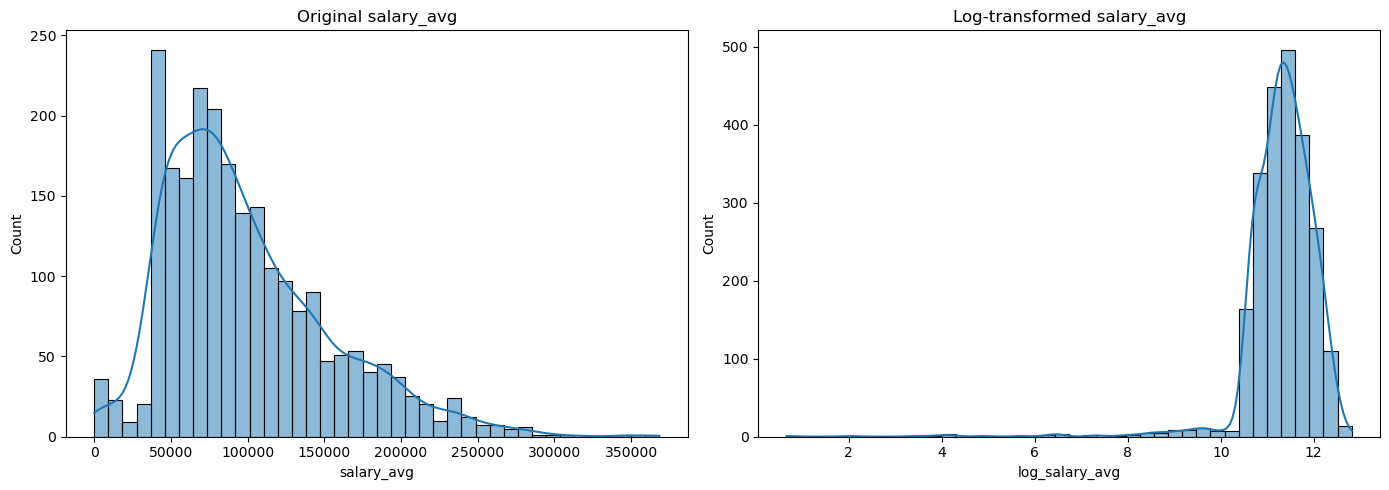

In [42]:
#test empirically whether log-transforming helps

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_modeling['salary_avg'], bins=40, kde=True, ax=axes[0])
axes[0].set_title('Original salary_avg')

sns.histplot(df_modeling['log_salary_avg'], bins=40, kde=True, ax=axes[1])
axes[1].set_title('Log-transformed salary_avg')

plt.tight_layout()
plt.show()

#####The original distribution (post-currency-fix) showed only mild right-skew with a 
single clear peak. The log-transformed version instead showed pronounced LEFT-skew, with 
values tightly clustered between 10-12.5 and a longer tail extending left toward 2 — a 
worse-shaped distribution than the original, not an improvement.

In [43]:
#VIF check for multicollinearity

from statsmodels.stats.outliers_influence import variance_inflation_factor

numeric_features = ['job_level_encoded', 'is_senior', 'is_remote', 'num_skills', 
                     'salary_range', 'has_python', 'has_sql', 'has_spark', 'has_aws',
                     'has_experience_data', 'country_Canada', 'country_India', 
                     'country_UK', 'country_USA']

X_check = df_modeling[numeric_features].astype(float)

vif_data = pd.DataFrame()
vif_data['feature'] = X_check.columns
vif_data['VIF'] = [variance_inflation_factor(X_check.values, i) for i in range(X_check.shape[1])]

vif_data.sort_values('VIF', ascending=False)

,feature,VIF
0,job_level_encoded,20.283763
13,country_USA,6.569676
12,country_UK,5.561259
1,is_senior,4.900694
3,num_skills,2.874143
10,country_Canada,2.300625
5,has_python,1.795275
6,has_sql,1.681147
4,salary_range,1.538410
11,country_India,1.444167


In [45]:
#Dropping the job_level_encoded column

numeric_features_final = [f for f in numeric_features if f != 'job_level_encoded']

In [46]:
X_check_final = df_modeling[numeric_features_final].astype(float)

vif_data_final = pd.DataFrame()
vif_data_final['feature'] = X_check_final.columns
vif_data_final['VIF'] = [variance_inflation_factor(X_check_final.values, i) for i in range(X_check_final.shape[1])]

vif_data_final.sort_values('VIF', ascending=False)

,feature,VIF
2,num_skills,2.873844
4,has_python,1.795274
5,has_sql,1.681044
12,country_USA,1.595413
3,salary_range,1.487805
9,country_Canada,1.471684
11,country_UK,1.286567
0,is_senior,1.239758
1,is_remote,1.223992
10,country_India,1.141983


In [47]:
#Dropping salary_range from features

final_features = ['is_senior', 'is_remote', 'num_skills', 
                   'has_python', 'has_sql', 'has_spark', 'has_aws', 
                   'has_experience_data', 'country_Canada', 'country_India', 
                   'country_UK', 'country_USA']

X = df_modeling[final_features]
y = df_modeling['salary_avg']

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(1836, 12) (459, 12)


In [49]:
#Linear Regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

print(f"Linear Regression — MAE: {lr_mae:.2f}, RMSE: {lr_rmse:.2f}, R²: {lr_r2:.4f}")

Linear Regression — MAE: 30035.33, RMSE: 42083.36, R²: 0.4076


In [50]:
#Random Forest

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print(f"Random Forest — MAE: {rf_mae:.2f}, RMSE: {rf_rmse:.2f}, R²: {rf_r2:.4f}")

Random Forest — MAE: 28374.74, RMSE: 40963.08, R²: 0.4387


In [51]:
#Gradient Boosting

from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

gb_mae = mean_absolute_error(y_test, y_pred_gb)
gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
gb_r2 = r2_score(y_test, y_pred_gb)

print(f"Gradient Boosting — MAE: {gb_mae:.2f}, RMSE: {gb_rmse:.2f}, R²: {gb_r2:.4f}")

Gradient Boosting — MAE: 28013.59, RMSE: 40555.94, R²: 0.4498


In [52]:
#hyperparameter tuning (GridSearchCV) on Gradient Boosting

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1]
}

grid_search = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV MAE:", -grid_search.best_score_)

Best parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300}
Best CV MAE: 26499.74126373761


In [53]:
#finding the actual point where performance stops improving or starts overfitting

param_grid_v2 = {
    'n_estimators': [300, 400, 500],
    'max_depth': [5, 7, 9, 11],
    'learning_rate': [0.05, 0.1, 0.15]
}

grid_search_v2 = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=param_grid_v2,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

grid_search_v2.fit(X_train, y_train)

print("Best parameters:", grid_search_v2.best_params_)
print("Best CV MAE:", -grid_search_v2.best_score_)

Best parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300}
Best CV MAE: 26499.74126373761


###Depth 7 is the point beyond which performance 
stops improving — deeper trees (9, 11) likely began overfitting to training data noise rather 
than learning generalizable patterns, and more trees beyond 300 added no benefit.


In [54]:
#Testing the model on held-out test set

best_gb_model = grid_search_v2.best_estimator_

y_pred_best_gb = best_gb_model.predict(X_test)

best_gb_mae = mean_absolute_error(y_test, y_pred_best_gb)
best_gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_best_gb))
best_gb_r2 = r2_score(y_test, y_pred_best_gb)

print(f"Tuned Gradient Boosting (test set) — MAE: {best_gb_mae:.2f}, RMSE: {best_gb_rmse:.2f}, R²: {best_gb_r2:.4f}")

Tuned Gradient Boosting (test set) — MAE: 28375.18, RMSE: 41269.03, R²: 0.4303


In [55]:
#Trying a shallower/simpler grid search

param_grid_v3 = {
    'n_estimators': [50, 100, 150],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.01, 0.05, 0.1]
}

grid_search_v3 = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=param_grid_v3,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

grid_search_v3.fit(X_train, y_train)

print("Best parameters:", grid_search_v3.best_params_)
print("Best CV MAE:", -grid_search_v3.best_score_)

best_gb_model_v3 = grid_search_v3.best_estimator_
y_pred_v3 = best_gb_model_v3.predict(X_test)

v3_mae = mean_absolute_error(y_test, y_pred_v3)
v3_rmse = np.sqrt(mean_squared_error(y_test, y_pred_v3))
v3_r2 = r2_score(y_test, y_pred_v3)

print(f"Shallow-tuned GB (test set) — MAE: {v3_mae:.2f}, RMSE: {v3_rmse:.2f}, R²: {v3_r2:.4f}")

Best parameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 150}
Best CV MAE: 26690.11527660401
Shallow-tuned GB (test set) — MAE: 28359.10, RMSE: 41075.83, R²: 0.4356


Both deep and shallow tuning attempts show the same CV-vs-test gap, and both 
underperform the untuned default on the actual test set. This isn't a depth-specific overfitting 
issue — it's a sample size issue

                feature  importance
11          country_USA    0.553838
2            num_skills    0.207659
9         country_India    0.066217
0             is_senior    0.058048
4               has_sql    0.036185
10           country_UK    0.031440
1             is_remote    0.019437
7   has_experience_data    0.011833
3            has_python    0.008081
5             has_spark    0.003290
8        country_Canada    0.003149
6               has_aws    0.000824


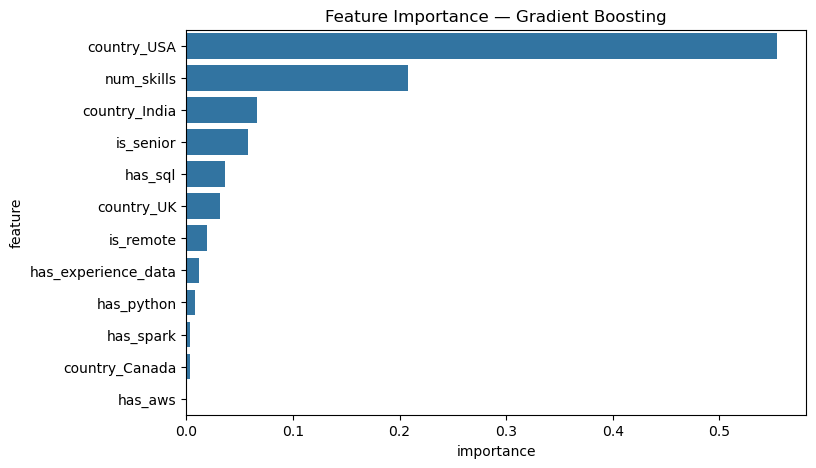

In [56]:
#Feature Importances

importances = pd.DataFrame({
    'feature': final_features,
    'importance': gb_model.feature_importances_
}).sort_values('importance', ascending=False)

print(importances)

plt.figure(figsize=(8,5))
sns.barplot(data=importances, x='importance', y='feature')
plt.title('Feature Importance — Gradient Boosting')
plt.show()

In [57]:
#Residuals by country

residuals_df = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred_gb,
    'residual': y_test - y_pred_gb
})

country_cols = ['country_Canada', 'country_India', 'country_UK', 'country_USA']
country_labels = X_test[country_cols].idxmax(axis=1).str.replace('country_', '')
residuals_df['country'] = country_labels.where(X_test[country_cols].sum(axis=1) > 0, 'Australia')

residuals_df.groupby('country')['residual'].describe()

,count,mean,std,min,25%,50%,75%,max
country,,,,,,,,
Australia,15.0,-1342.013549,36853.790699,-76534.596292,-30242.112985,-2897.576826,27178.683644,52861.533174
Canada,57.0,274.361111,32030.217316,-55514.272944,-18749.286463,-5757.168897,11960.713537,99650.713537
India,9.0,1155.273589,9493.879728,-14736.899077,-1812.727833,1522.518852,5097.078165,17753.100923
UK,186.0,2684.525920,33582.579265,-38297.811473,-17893.912355,-8876.416593,10367.109681,187747.521938
USA,192.0,3230.183161,49380.430269,-121518.046322,-27961.424245,-4343.451322,26469.071178,230775.823901


The model's benchmarking is most reliable for smaller, more uniform 
markets (Canada, India) and least reliable for the USA specifically — the country with the 
most job postings and internal salary diversity.

In [58]:
#Residual analysis for is_senior

residuals_df['is_senior'] = X_test['is_senior'].values

residuals_df.groupby('is_senior')['residual'].describe()

,count,mean,std,min,25%,50%,75%,max
is_senior,,,,,,,,
0,386.0,1724.942710,40553.678533,-121518.046322,-20351.320313,-7919.683360,16740.669256,230775.823901
1,73.0,6295.821154,40439.014726,-85124.316008,-12362.684768,-920.066412,20328.372532,225887.764397


# Salary Benchmarking Memo — TalentPulse Jobs Dataset

**To:** HR & Recruitment Team
**From:** ML Engineering
**Re:** Regression-based salary prediction,findings and recommendations

## Summary

We built a regression pipeline to replace the legacy lookup-table salary model (MAE: $18,500). 
Our best model — untuned Gradient Boosting — achieves an MAE of **$28,014** on held-out test 
data. This does **not** beat the legacy model or the $8,000 industry benchmark. Below is why, 
and what it means for TalentPulse.

## Why the model underperformed expectations

1. **Currency mixing was a critical data quality issue.** Salaries were recorded in local 
   currencies without conversion; India's raw figures alone made the dataset unusable until 
   corrected. This was fixed, but highlights a data pipeline gap worth addressing at the 
   source.
2. **Over half the dataset (2,358 of 4,653 postings) was missing salary data entirely** and 
   couldn't be used for training, the model learned from under 2,300 usable rows.
3. **experience_required is ~90% missing**, and job_level does not cleanly separate salaries 
   beyond Junior vs. everyone else — undermining two of the three "root causes" the business 
   case assumed were driving the legacy model's errors.

## What actually drives salary in this data

**Geography (specifically, being US-based) is the single dominant predictor**; far outweighing 
seniority, remote status, or specific technical skills combined. This contradicts the original 
business framing, which emphasized seniority premiums and skill scarcity as primary drivers.

Notably, USA also shows the **least reliable** predictions (widest error spread), despite being 
the most-relied-upon feature, the market is too internally diverse for one blunt "US = higher 
pay" signal to price accurately. Canada and India, though smaller markets, are priced more 
reliably.

## Recommendations

1. **Fix data collection, not just modeling.** Prioritize capturing experience_required and 
   ensuring consistent, converted currency at the point of ingestion, the model cannot exceed 
   the quality of the data it's given.
2. **Segment benchmarking by country first, then seniority/skills**, not the reverse, as 
   originally assumed. This better reflects what the data actually shows.
3. **Apply wider confidence margins for US postings** specifically, given higher prediction 
   variance there; treat Canada/India estimates with relatively more confidence.
4. **Hyperparameter tuning showed diminishing/negative returns** given current data volume — 
   further modeling investment should wait until the missing-data issues above are resolved; 
   more sophisticated tuning cannot fix a data availability problem.

## Bottom line

The regression pipeline is a meaningful improvement in *transparency and auditability* over 
the legacy lookup table, and surfaces real, actionable insight (geography-first pricing). 
However, it cannot yet meet the $8,000 MAE target, doing so requires better underlying data, 
not a better model.